# Regresja 
Estymacja ceny mieszkań na podstawie zbioru danych **AmesHousing**

### Importowanie potrzebnych bibliotek

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

### Wczytywanie danych

In [142]:
df = pd.read_csv("domy.csv", index_col=[0], na_values=['?'])
df_copy = df.copy()

### Wstępna analiza danych

In [143]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

W zbiorze danych występują braki danych. </br> Według dokumentacji niektóre z nich zostały umieszczone celowo.

In [144]:
missing_values = df.isna().sum()
missing_values[missing_values > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

Niektóre zmienne nie posiadają wszystkich wartości opisanych w dokumentacji

Brak wartości *CBlock*

Text(0.5, 1.0, 'Hisogram zmiennej MasVnrType')

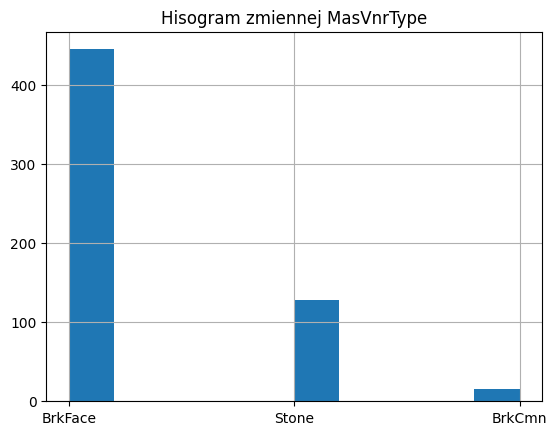

In [145]:
df.MasVnrType.hist()
plt.title("Hisogram zmiennej MasVnrType")

Brak wartości *Po*

Text(0.5, 1.0, 'Histogram zmiennej BsmtQual')

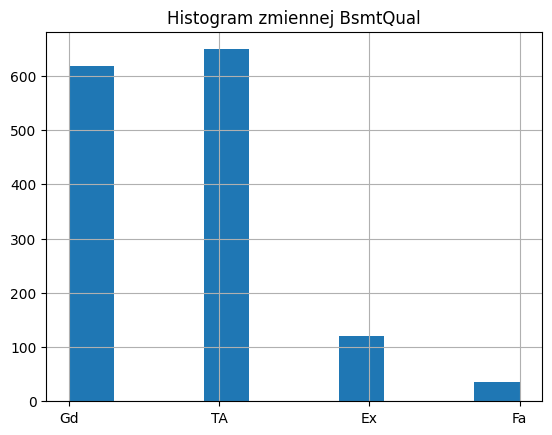

In [146]:
df.BsmtQual.hist()
plt.title("Histogram zmiennej BsmtQual")

Brak wartości *Ex*

Text(0.5, 1.0, 'Histogram zmiennej BsmtCond')

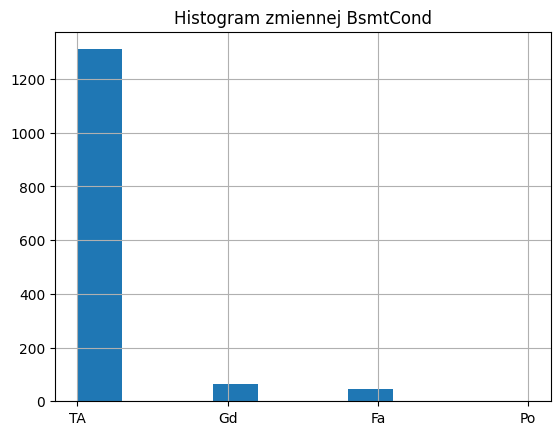

In [147]:
df.BsmtCond.hist()
plt.title("Histogram zmiennej BsmtCond")

### Preprocessing danych

##### Dealing with false N/A values

In [148]:
df.loc[df.LotFrontage.isna(), "LotFrontage"] = 0

##### Missing values

In [149]:
print("MasVnrArea")
print(f"Values equal to zero: {df.MasVnrArea[df.MasVnrArea == 0].count()}   <-- lack of masonry veneer")
print(f"Missing values:")
print(df.MasVnrArea[df.MasVnrArea.isna()])
print(df.MasVnrType[df.MasVnrArea.isna()])
df.MasVnrArea = df.MasVnrArea.fillna(0.0)
df.GarageYrBlt = df.GarageYrBlt.fillna(df.YearBuilt)

df.dropna(subset=["Electrical"], inplace=True)


MasVnrArea
Values equal to zero: 861   <-- lack of masonry veneer
Missing values:
Id
235    NaN
530    NaN
651    NaN
937    NaN
974    NaN
978    NaN
1244   NaN
1279   NaN
Name: MasVnrArea, dtype: float64
Id
235     NaN
530     NaN
651     NaN
937     NaN
974     NaN
978     NaN
1244    NaN
1279    NaN
Name: MasVnrType, dtype: str


##### One-hot encoding
TODO: Condition 1 and 2 merge, and Exterior 1/2
Misc feature to set as val

In [150]:
nominal_columns = ["MSSubClass", "MSZoning", "Street", "LandContour", "LotConfig", 
                   "Neighborhood", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Foundation",
                   "Heating", "CentralAir", "SaleType", "SaleCondition", "Condition1", "Condition2",
                   "Exterior1st", "Exterior2nd"]
nominal_columns_na = ["Alley", "MasVnrType", "GarageType", "MiscFeature"]
df = pd.get_dummies(df, drop_first=True, columns=nominal_columns)
df = pd.get_dummies(df, drop_first=False, columns=nominal_columns_na)

Zbiór danych zawiera *Misc features*, oraz ich wartości. <br>
Pomysł enkodowania obecności *Misc features* poprzez ich wartości może tracić informacje - 2 rekordy z istnejącą cechą mają wartość 0.0

In [151]:
# misc_feat = pd.get_dummies(df.MiscFeature, drop_first=False, dtype=np.float64)

# misc_feat.mul(df.MiscVal, axis=0).head(20)
# print(f"No miscelaneous feature count:        {len(df.MiscFeature[df.MiscFeature.isna()])}")
# print(f"Miscelaneous feature value = 0 count: {df.MiscVal[df.MiscVal == 0.0].count()}")
#misc_feat.head(20)

##### Ordinal encoding

In [152]:
lot_shape_mapping = {
    'Reg': 0.0,
    'IR1': 1.0/3.0,
    'IR2': 2.0/3.0,
    'IR3': 1.0
}
df.LotShape = df.LotShape.map(lot_shape_mapping)
print(df.LotShape.dtype)

utilities_mapping = {
    'ELO': 0.0,
    'NoSeWa': 1.0/3.0,
    'NoSewr': 2.0/3.0,
    'AllPub': 1.0
}
df.Utilities = df.Utilities.map(utilities_mapping)

land_slope_mapping = {
    'Gtl': 0.0,
    'Mod': 1.0/2.0,
    'Sev': 1.0
}
df.LandSlope = df.LandSlope.map(land_slope_mapping)

qual_mapping = {
    'Po': 0.0,
    'Fa': 1.0/4.0,
    'TA': 2.0/4.0,
    'Gd': 3.0/4.0,
    'Ex': 1.0
}
df.ExterQual = df.ExterQual.map(qual_mapping)
df.ExterCond = df.ExterCond.map(qual_mapping)
df.HeatingQC = df.HeatingQC.map(qual_mapping)
df.KitchenQual = df.KitchenQual.map(qual_mapping)

qual_mapping_na = {
    np.nan: 0.0,
    'Po': 1.0/5.0,
    'Fa': 2.0/5.0,
    'TA': 3.0/5.0,
    'Gd': 4.0/5.0,
    'Ex': 1.0
}
df.BsmtQual = df.BsmtQual.map(qual_mapping_na)
df.BsmtCond = df.BsmtCond.map(qual_mapping_na)
df.FireplaceQu = df.FireplaceQu.map(qual_mapping_na)
df.GarageQual = df.GarageQual.map(qual_mapping_na)
df.GarageCond = df.GarageCond.map(qual_mapping_na)
df.PoolQC = df.PoolQC.map(qual_mapping_na)

bsmt_exposure_mapping = {
    np.nan: 0.0,
    'No': 0.0,
    'Mn': 1.0/3.0,
    'Av': 2.0/3.0,
    'Gd': 1.0
}
df.BsmtExposure = df.BsmtExposure.map(bsmt_exposure_mapping)

bsmt_fin_type_mapping = {
    np.nan: 0.0,
    'Unf': 1.0/6.0,
    'LwQ': 2.0/6.0,
    'Rec': 3.0/6.0,
    'BLQ': 4.0/6.0,
    'ALQ': 5.0/6.0,
    'GLQ': 1.0
}
df.BsmtFinType1 = df.BsmtFinType1.map(bsmt_fin_type_mapping)
df.BsmtFinType2 = df.BsmtFinType2.map(bsmt_fin_type_mapping)

electrical_mapping = {
    'FuseP': 0.0,
    'Mix': 1.0/4.0,
    'FuseF': 2.0/4.0,
    'FuseA': 3.0/4.0,
    'SBrkr': 1.0
}
df.Electrical = df.Electrical.map(electrical_mapping)

functional_mapping = {
    'Sal': 0.0,
    'Sev': 1.0/7.0,
    'Maj2': 2.0/7.0,
    'Maj1': 3.0/7.0,
    'Mod': 4.0/7.0,
    'Min2': 5.0/7.0,
    'Min1': 6.0/7.0,
    'Typ': 1.0
}
df.Functional = df.Functional.map(functional_mapping)

garage_finish_mapping = {
    np.nan: 0.0,
    'Unf': 1.0/3.0,
    'RFn': 2.0/3.0,
    'Fin': 1.0
}
df.GarageFinish = df.GarageFinish.map(garage_finish_mapping)

paved_drive_mapping = {
    'N': 0.0,
    'P': 1.0/2.0,
    'Y': 1.0
}
df.PavedDrive = df.PavedDrive.map(paved_drive_mapping)

fence_mapping = {
    np.nan: 0.0,
    'MnWw': 1.0/4.0,
    'GdWo': 2.0/4.0,
    'MnPrv': 3.0/4.0,
    'GdPrv': 1.0
}
df.Fence = df.Fence.map(fence_mapping)

float64


Odrzucenie outlierów zalecane przez dokumentacją

<Figure size 640x480 with 0 Axes>

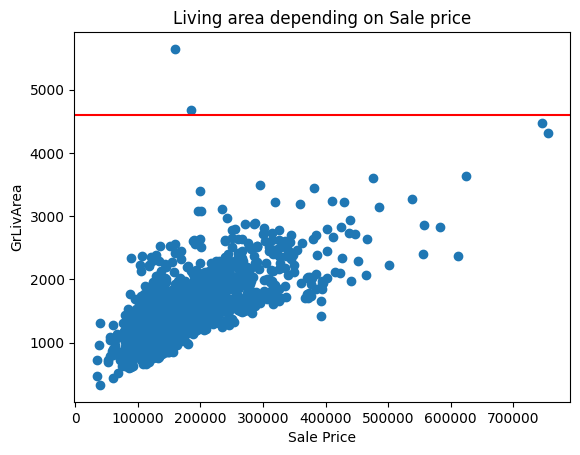

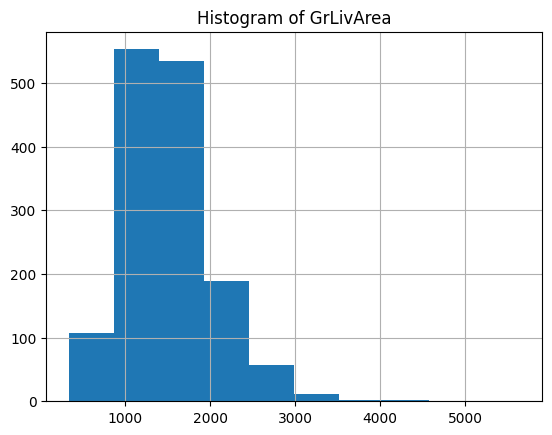

<Figure size 640x480 with 0 Axes>

In [153]:
plt.scatter(df.SalePrice, df.GrLivArea)
plt.title("Living area depending on Sale price")
plt.xlabel("Sale Price")
plt.ylabel("GrLivArea")
plt.axhline(4600, color="red")
plt.figure()
df["GrLivArea"].hist()
plt.title("Histogram of GrLivArea")
df = df[df.GrLivArea <= 4600]
plt.figure()

Heterodeskatyczność *Sale price*</br>
Zastosowano metodę zalecaną w dokumentacji

Text(0.5, 1.0, 'Histogram log(SalePrice)')

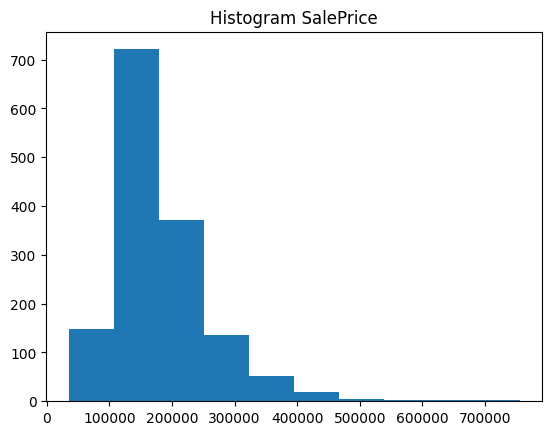

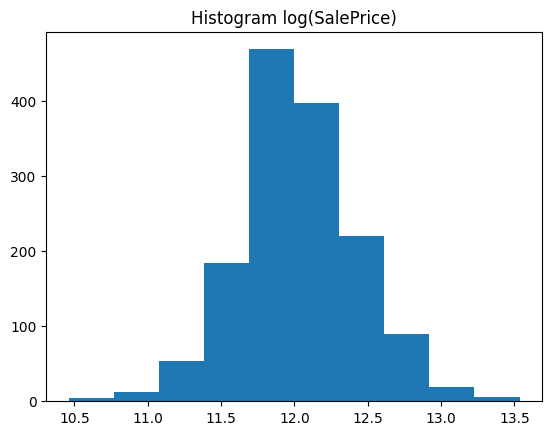

In [154]:
plt.hist(df.SalePrice)
plt.title("Histogram SalePrice")
df.SalePrice = np.log(df.SalePrice)
plt.figure()
plt.hist(df.SalePrice)
plt.title("Histogram log(SalePrice)")

Podział danych na dane wejściowe i zmienną estymowaną, oraz normalizacja danych do wartości z zakresu 0.0-1.0

In [155]:
Y = df.SalePrice
X = df.drop(["SalePrice"], axis=1)
X = X.astype(np.float64)
X_unnormalized = X
X = (X - X.min()) / (X.max() - X.min())
X.describe()

,LotFrontage,LotArea,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,MiscFeature_Gar2,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC
count,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,...,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000
mean,0.183348,0.042817,0.135438,0.999314,0.031229,0.566079,0.572066,0.718799,0.580313,0.063913,...,0.004118,0.596431,0.013040,0.059025,0.006177,0.265614,0.001373,0.001373,0.033631,0.000686
std,0.108602,0.046099,0.192872,0.026198,0.138251,0.152949,0.139205,0.218771,0.344011,0.111970,...,0.064062,0.490781,0.113487,0.235753,0.078378,0.441811,0.037037,0.037037,0.180339,0.026198
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.134185,0.029166,0.000000,1.000000,0.000000,0.444444,0.500000,0.594203,0.283333,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.201278,0.038201,0.000000,1.000000,0.000000,0.555556,0.500000,0.724638,0.733333,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.252396,0.048143,0.333333,1.000000,0.000000,0.666667,0.625000,0.927536,0.900000,0.102500,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Analiza danych

Data wybudowania domu niekoniecznie zmniejsza jego cenę

Text(0, 0.5, 'Cena mieszkania')

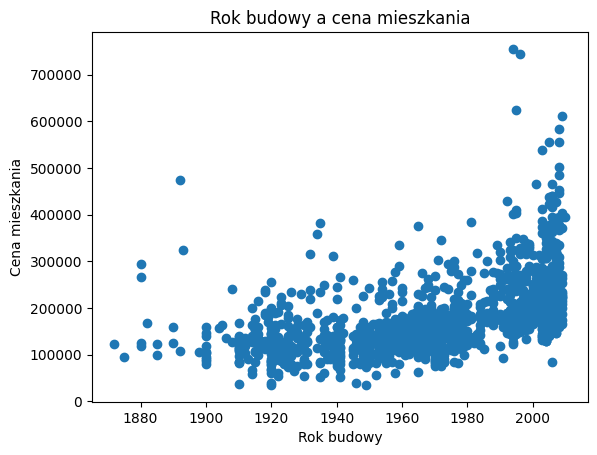

In [156]:
plt.scatter(df_copy.YearBuilt, df_copy.SalePrice)
plt.title("Rok budowy a cena mieszkania")
plt.xlabel("Rok budowy")
plt.ylabel("Cena mieszkania")

Wpływ dodatkowych cech *Condition 1/2* na SalePrice

<Axes: title={'center': 'SalePrice'}, xlabel='Condition2'>

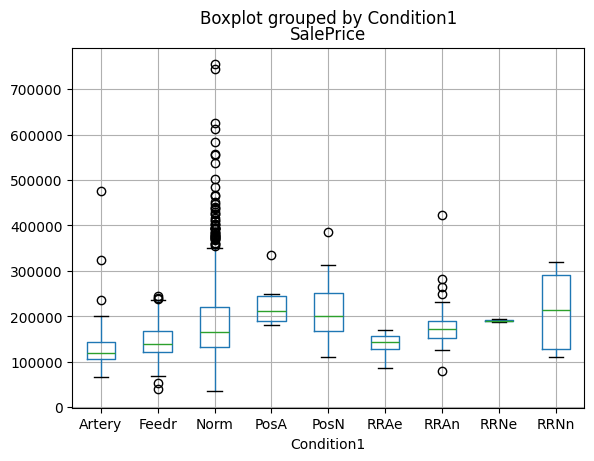

<Figure size 640x480 with 0 Axes>

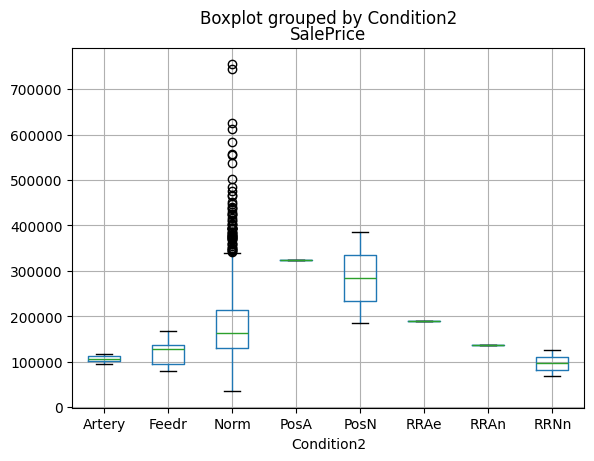

In [157]:
df_copy.boxplot(by="Condition1", column="SalePrice")
plt.figure()
df_copy.boxplot(by="Condition2", column="SalePrice")

##### Analiza korelacji

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,-0.065649,0.049900,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.072319,-0.050117,1.000000,...,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378


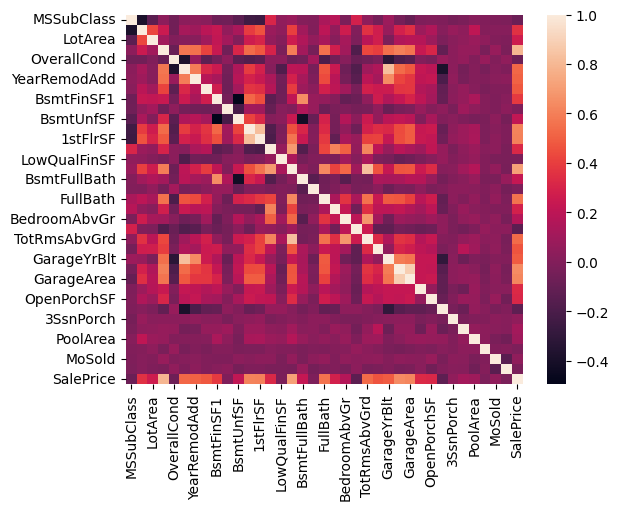

In [158]:
sns.heatmap(df_copy.corr(numeric_only=True))
df_copy.corr(numeric_only=True)

Wysoką korelację z ceną końcową (na poziomie ~0.75) mają ogólna jakość mieszkania oraz powierzchnia mieszkalna. </br>
Zauważalną korelację z ceną końcową (na poziomie ~0.5) mają rok produkcji i remontu, powierzchnia piwnicy, pojemność garażu, ilość pełnych łazienek oraz obecność kominka.

<Axes: >

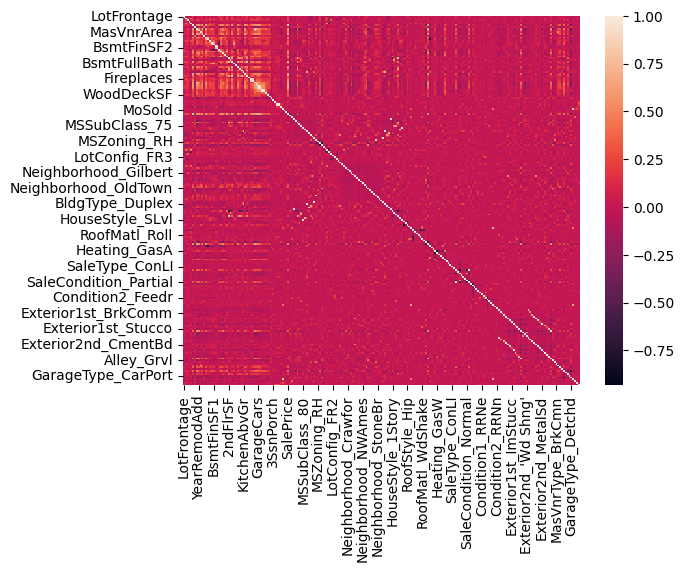

In [159]:
sns.heatmap(df.corr())

### Użycie modeli
Ustawienie ziarna lsowości aby zachować powtarzalność wyników

In [160]:
sk.random.seed(1234)

In [161]:
from sklearn.model_selection import KFold, RepeatedKFold
k_fold = KFold(shuffle=True, random_state=1234)
train_ind = []
test_ind = []
for train_index, test_index in k_fold.split(X):
    train_ind.append(train_index)
    test_ind.append(test_index)

cv = list(zip(train_ind, test_ind))

r_k_fold = RepeatedKFold(n_repeats=20, random_state=1234)
r_train_ind = []
r_test_ind = []
for train_index, test_index in r_k_fold.split(X):
    r_train_ind.append(train_index)
    r_test_ind.append(test_index)

##### Regresja liniowa

count    100.000000
mean       0.901127
std        0.015795
min        0.857705
25%        0.891223
50%        0.902635
75%        0.913014
max        0.932957
dtype: float64


Text(0.5, 1.0, 'Histogram of R^2 score for linear regression')

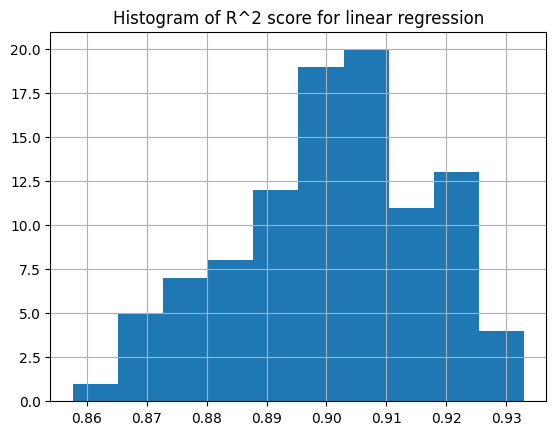

In [162]:
from sklearn.linear_model import LinearRegression

scores_lr = []

for i in range(100):
    model = LinearRegression(copy_X=True)
    model.fit(X.iloc[r_train_ind[i]], Y.iloc[r_train_ind[i]])
    scores_lr.append(model.score(X.iloc[r_test_ind[i]], Y.iloc[r_test_ind[i]]))
lr = pd.Series(scores_lr)
print(lr.describe())
lr.hist()
plt.title("Histogram of R^2 score for linear regression")

Alpha: 1.0
count    100.000000
mean       0.915417
std        0.014018
min        0.880999
25%        0.907007
50%        0.916560
75%        0.925937
max        0.943621
dtype: float64


Text(0.5, 1.0, 'Histogram of R^2 score for ridge regression')

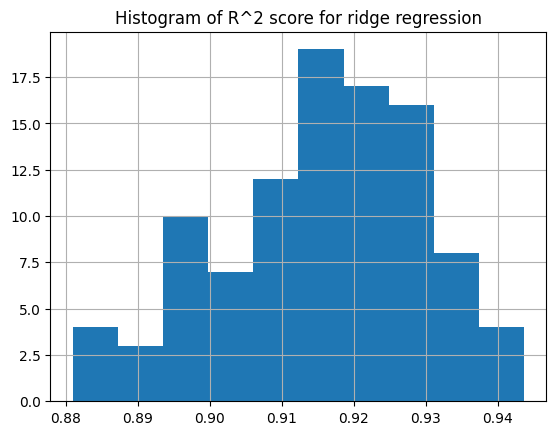

In [163]:
from sklearn.linear_model import Ridge, RidgeCV

alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]

model_cv = RidgeCV(
    alphas=alphas_to_test, 
    cv=cv,
    scoring='r2',
)

model_cv.fit(X, Y)

print(f"Alpha: {model_cv.alpha_}")

scores_r = []

for i in range(100):
    model = Ridge(copy_X=True, alpha=model_cv.alpha_, random_state=1234)
    model.fit(X.iloc[r_train_ind[i]], Y.iloc[r_train_ind[i]])
    scores_r.append(model.score(X.iloc[r_test_ind[i]], Y.iloc[r_test_ind[i]]))
r = pd.Series(scores_r)
print(r.describe())
r.hist()
plt.title("Histogram of R^2 score for ridge regression")

Alpha: 0.01
count    100.000000
mean       0.814702
std        0.017415
min        0.761021
25%        0.803187
50%        0.814557
75%        0.827295
max        0.860254
dtype: float64


Text(0.5, 1.0, 'Histogram of R^2 score for lasso regression')

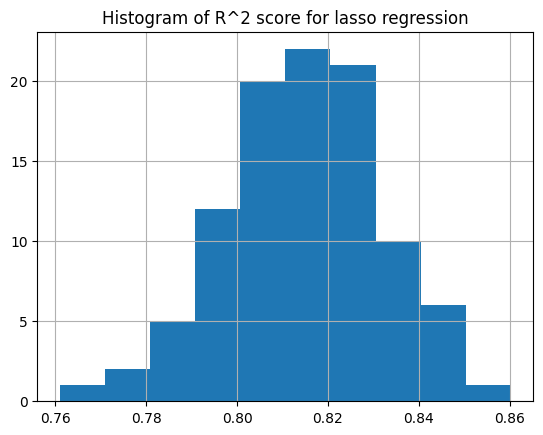

In [164]:
from sklearn.linear_model import Lasso, LassoCV

alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]

model_cv = LassoCV(
    alphas=alphas_to_test, 
    cv=cv,
    random_state=1234
)

model_cv.fit(X, Y)

print(f"Alpha: {model_cv.alpha_}")

scores_l = []

for i in range(100):
    model = Lasso(copy_X=True, alpha=model_cv.alpha_, random_state=1234)
    model.fit(X.iloc[r_train_ind[i]], Y.iloc[r_train_ind[i]])
    scores_l.append(model.score(X.iloc[r_test_ind[i]], Y.iloc[r_test_ind[i]]))
l = pd.Series(scores_l)
print(l.describe())
l.hist()
plt.title("Histogram of R^2 score for lasso regression")

count    100.000000
mean       0.837192
std        0.021616
min        0.774280
25%        0.824091
50%        0.840072
75%        0.851234
max        0.879933
dtype: float64


Text(0.5, 1.0, 'Histogram of R^2 score for polynomial regression (degree=2)')

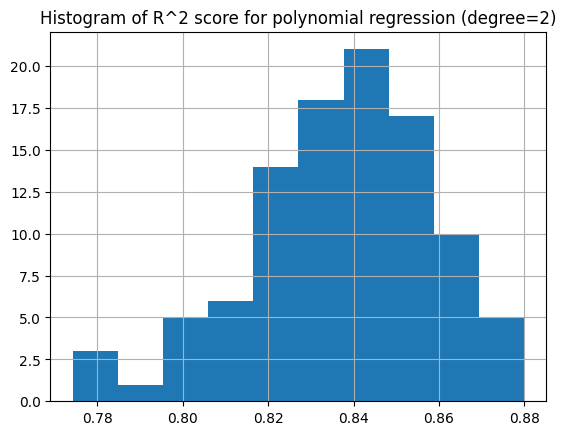

In [165]:
import gc
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

X_np = X.to_numpy()
Y_np = Y.to_numpy()

scores_poly = []

for i in range(100):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression(copy_X=False))
    ])
    
    model.fit(X_np[r_train_ind[i]], Y_np[r_train_ind[i]])
    
    scores_poly.append(model.score(X_np[r_test_ind[i]], Y_np[r_test_ind[i]]))
    
    gc.collect()

poly = pd.Series(scores_poly)

print(poly.describe())
poly.hist()
plt.title("Histogram of R^2 score for polynomial regression (degree=2)")

##### Random forest

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 200}
count    100.000000
mean       0.879793
std        0.018323
min        0.828019
25%        0.869733
50%        0.882677
75%        0.893645
max        0.919044
dtype: float64


Text(0.5, 1.0, 'Histogram of R^2 score for random forest regression')

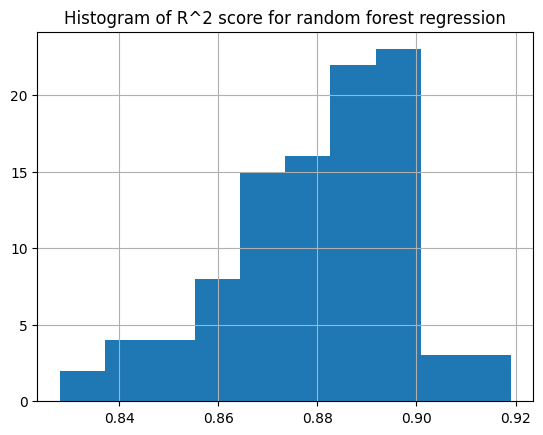

In [166]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=1234),
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
)

grid_search.fit(X, Y)

best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

scores_rf = []

for i in range(100):
    model = RandomForestRegressor(**best_params, random_state=1234)
    
    model.fit(X.iloc[r_train_ind[i]], Y.iloc[r_train_ind[i]])
    
    scores_rf.append(model.score(X.iloc[r_test_ind[i]], Y.iloc[r_test_ind[i]]))

rf = pd.Series(scores_rf)

print(rf.describe())
rf.hist()
plt.title("Histogram of R^2 score for random forest regression")

Bez normalizacji:

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 200}
count    100.000000
mean       0.879854
std        0.018311
min        0.828242
25%        0.869802
50%        0.882642
75%        0.893852
max        0.919112
dtype: float64


Text(0.5, 1.0, 'Histogram of R^2 score for random forest regression')

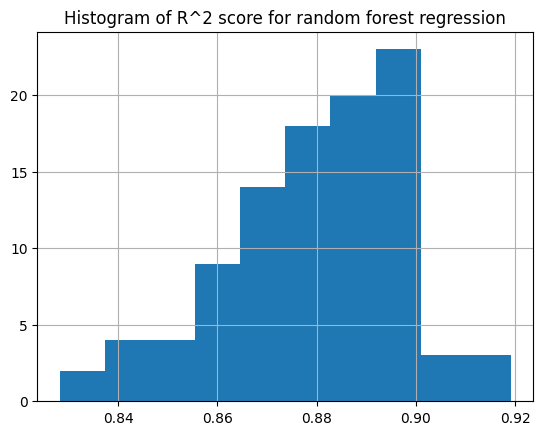

In [167]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=1234),
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
)

grid_search.fit(X_unnormalized, Y)

best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

scores_rf = []

for i in range(100):
    model = RandomForestRegressor(**best_params, random_state=1234)
    
    model.fit(X_unnormalized.iloc[r_train_ind[i]], Y.iloc[r_train_ind[i]])
    
    scores_rf.append(model.score(X_unnormalized.iloc[r_test_ind[i]], Y.iloc[r_test_ind[i]]))

rf = pd.Series(scores_rf)

print(rf.describe())
rf.hist()
plt.title("Histogram of R^2 score for random forest regression")

##### K-nearest neighbour regressor

Best Parameters: {'n_neighbors': 7, 'weights': 'distance'}
count    100.000000
mean       0.752870
std        0.023058
min        0.697506
25%        0.740625
50%        0.750711
75%        0.769337
max        0.811214
dtype: float64


Text(0.5, 1.0, 'Histogram of R^2 score for knn regression')

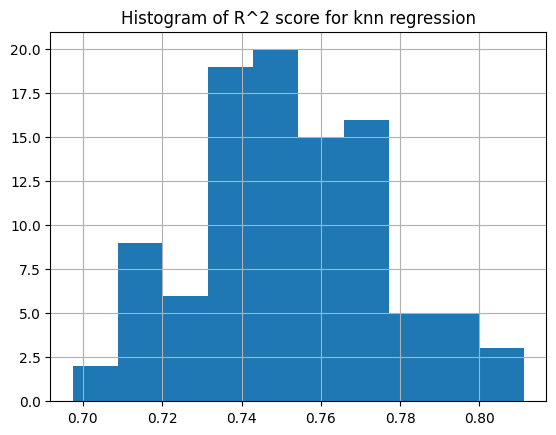

In [168]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X, Y)

best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

scores_knn = []

for i in range(100):
    model = KNeighborsRegressor(**best_params)
    
    model.fit(X.iloc[r_train_ind[i]], Y.iloc[r_train_ind[i]])
    
    scores_knn.append(model.score(X.iloc[r_test_ind[i]], Y.iloc[r_test_ind[i]]))

knn = pd.Series(scores_knn)

print(knn.describe())
knn.hist()
plt.title("Histogram of R^2 score for knn regression")

In [169]:
knn.describe()

count    100.000000
mean       0.752870
std        0.023058
min        0.697506
25%        0.740625
50%        0.750711
75%        0.769337
max        0.811214
dtype: float64

### Wyjaśnialność

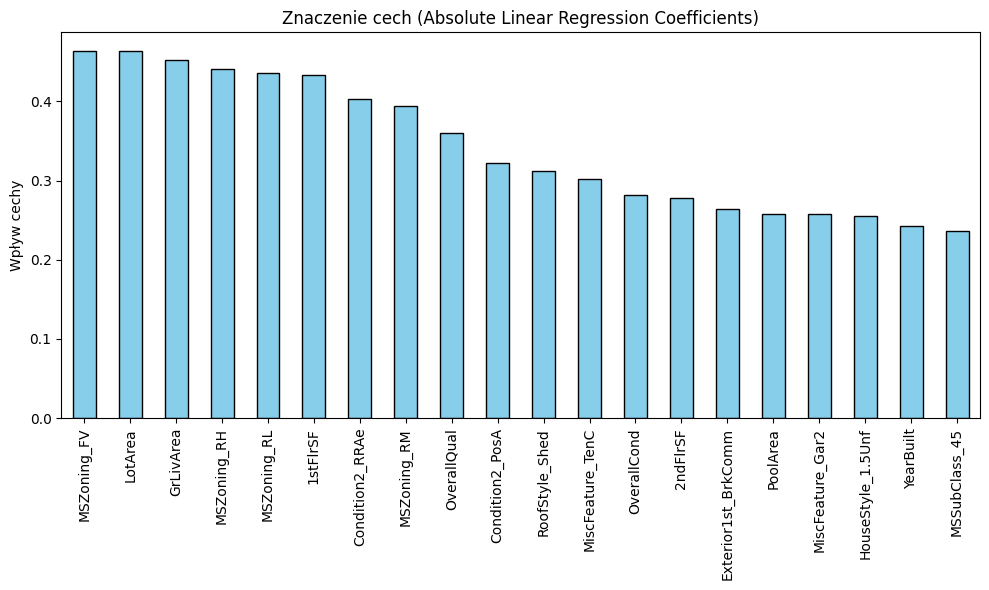

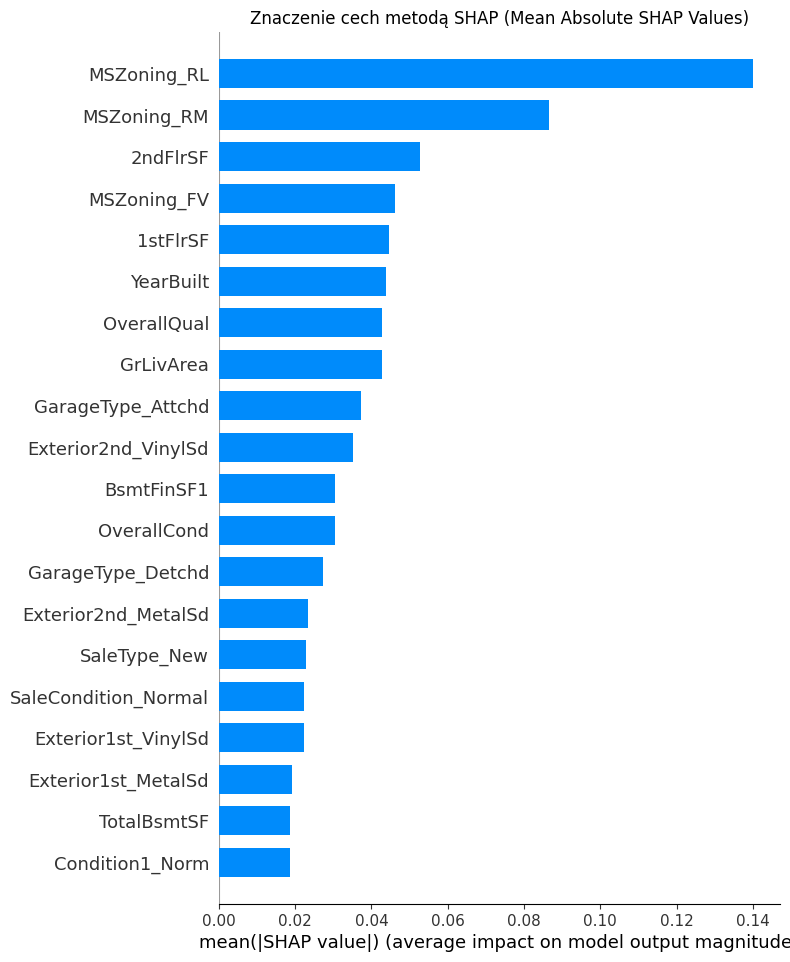

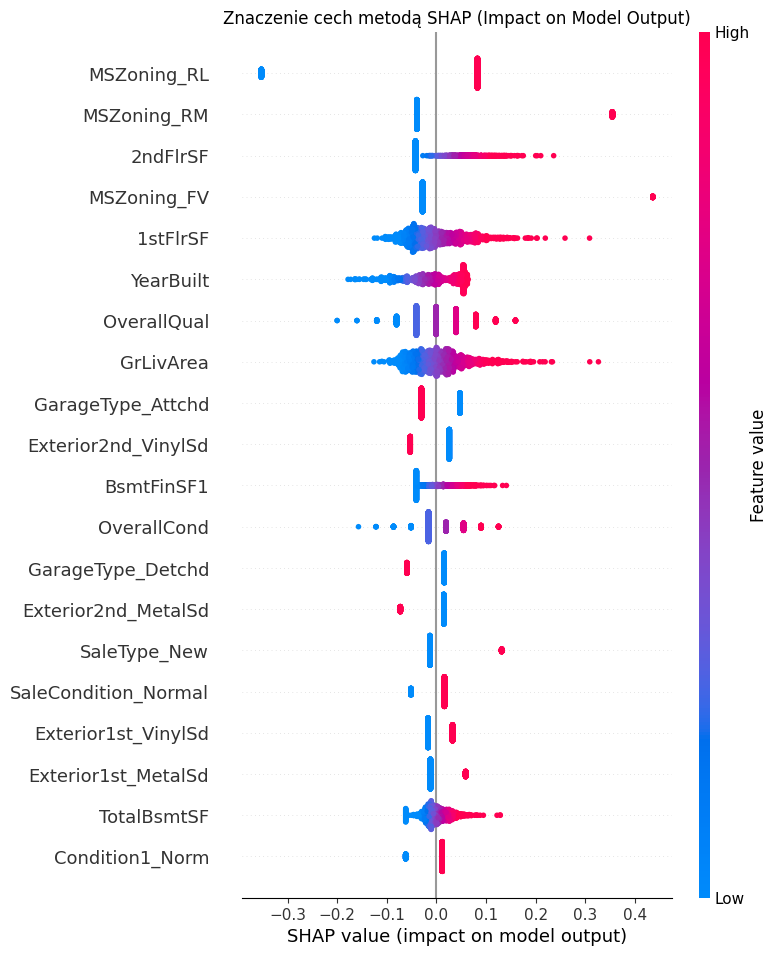

In [ ]:
import shap

model = LinearRegression()
model.fit(X, Y)

importance_lr = pd.Series(model.coef_, index=X.columns)
importance_lr_abs = importance_lr.abs().sort_values(ascending=False)[0:20]

importance_lr_abs.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title("Znaczenie cech (Absolute Linear Regression Coefficients)")
plt.ylabel("Wpływ cechy")
plt.tight_layout()
plt.show()

explainer = shap.LinearExplainer(model, X)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title("Znaczenie cech metodą SHAP (Mean Absolute SHAP Values)")
plt.show()

shap.summary_plot(shap_values, X, show=False)
plt.title("Znaczenie cech metodą SHAP (Impact on Model Output)")
plt.show()